# Phase 1 — Offline ECM Fit

**Goal:** Fit a static first-order Thevenin ECM (R₀, R₁, C₁) to the CALCE A1-007 OCV test data.  
Simulate voltage forward and plot measured vs predicted. Quote the RMSE — this is the **baseline** that the online RLS estimator in Phase 2 must beat.

### The model
```
V_t[k] = V_oc(SOC[k]) - R0·I[k] - V_rc[k]
V_rc[k+1] = V_rc[k]·exp(-dt/τ) + R1·(1 - exp(-dt/τ))·I[k]     where τ = R1·C1
SOC[k+1]  = SOC[k] - (I[k]·dt) / Q_nom
```

### This notebook
1. Pull A1-007 data from battdb
2. Extract OCV curve from rest periods
3. Fit R₀/R₁/C₁ using least squares on a pulse window
4. Simulate the full test with those fixed parameters
5. Plot measured vs predicted voltage
6. Compute RMSE — the Phase 1 baseline

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.interpolate import interp1d

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.2,
})

print('Imports OK')

Imports OK


## 2. Pull A1-007 data from battdb

In [3]:
conn = psycopg2.connect(
    host='localhost', port=5454,
    dbname='battdb', user='postgres', password='password'
)

query = """
    SELECT
        td.test_time_s,
        td.current_ma  / 1000.0  AS current_a,
        td.voltage_mv  / 1000.0  AS voltage_v,
        td.step,
        td.cycle,
        (td.other_details->>'temperature_1_c')::float AS temp_c
    FROM test_data td
    JOIN test_meta tm ON td.test_id = tm.test_id
    WHERE tm.test_name = 'CALCE_A1-007_OCV_neg10C_20120629'
    ORDER BY td.test_time_s
"""

df = pd.read_sql(query, conn)
conn.close()

print(f'Rows: {len(df):,}')
print(f'Duration: {df.test_time_s.max()/3600:.1f} hours')
print(f'Voltage: {df.voltage_v.min():.3f} - {df.voltage_v.max():.3f} V')
print(f'Current: {df.current_a.min():.3f} - {df.current_a.max():.3f} A')
print(f'Steps: {sorted(df.step.unique())}')
df.head()

C:\Users\Vcpat\AppData\Local\Temp\ipykernel_46664\3322979862.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Rows: 59,570
Duration: 44.2 hours
Voltage: 2.000 - 3.918 V
Current: -0.050 - 1.151 A
Steps: [1, 2, 3, 4, 5, 6, 7, 8]


,test_time_s,current_a,voltage_v,step,cycle,temp_c
0,3.011,0.000000,3.480732,1,1,None
1,3.011,0.000000,3.480732,1,1,None
2,3.027,1.151195,3.917767,2,1,None
3,3.027,1.151195,3.917767,2,1,None
4,8.036,0.205528,3.601070,3,1,None


## 3. Plot the raw data — understand the signal

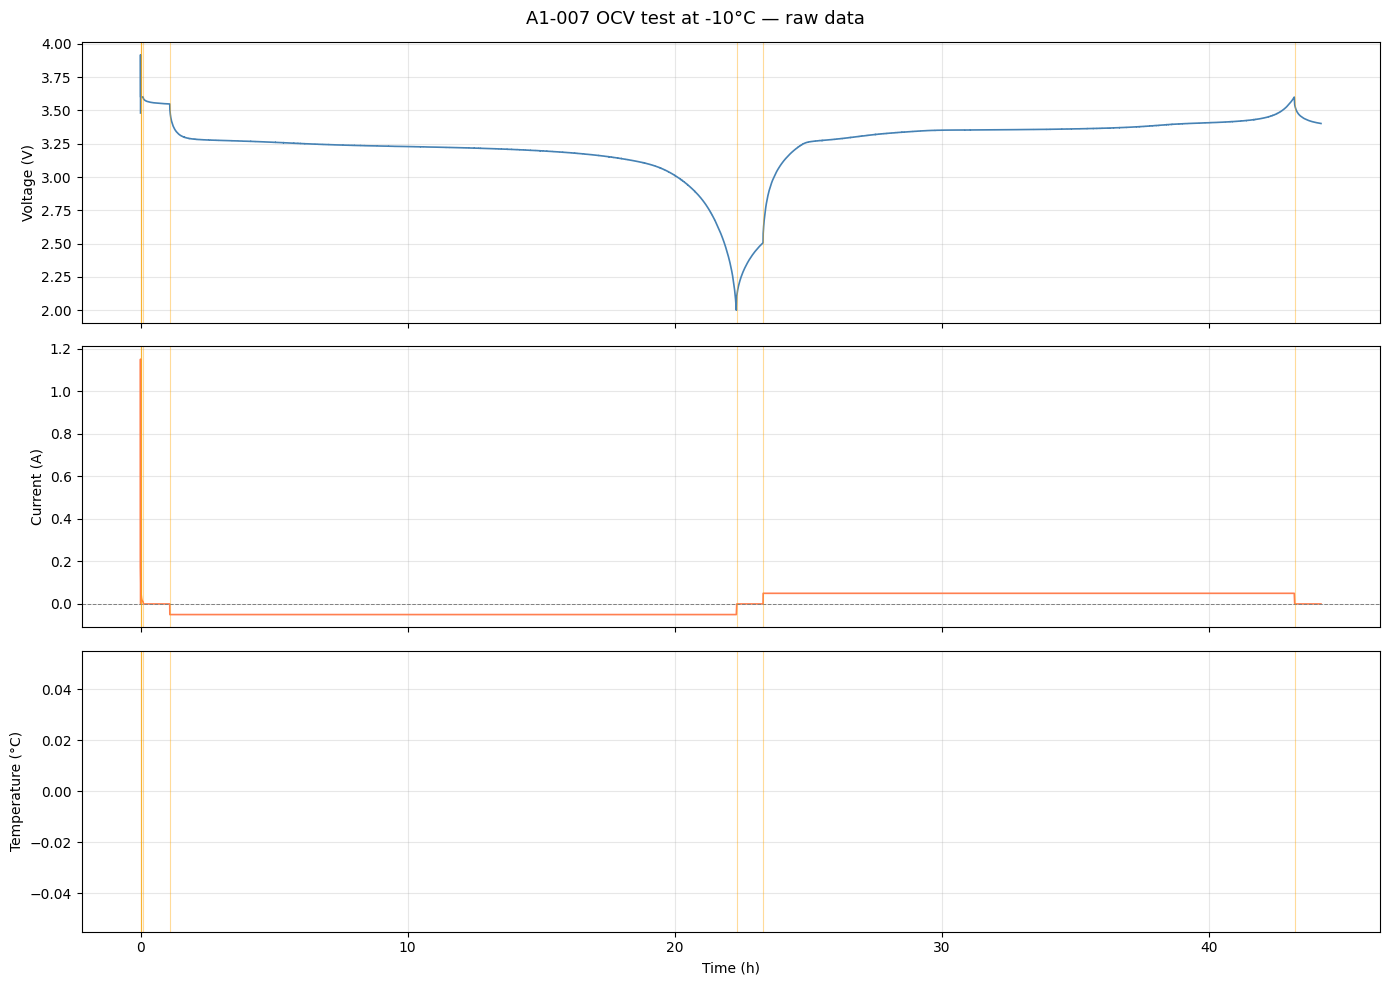

Orange lines = step boundaries


In [4]:
t = df['test_time_s'] / 3600  # hours

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('A1-007 OCV test at -10°C — raw data', fontsize=13)

axes[0].plot(t, df['voltage_v'], color='steelblue')
axes[0].set_ylabel('Voltage (V)')

axes[1].plot(t, df['current_a'], color='coral')
axes[1].set_ylabel('Current (A)')
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')

axes[2].plot(t, df['temp_c'], color='seagreen')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Time (h)')

# Mark step changes
for step_id in df['step'].unique():
    step_start = df[df['step'] == step_id]['test_time_s'].iloc[0] / 3600
    for ax in axes:
        ax.axvline(step_start, color='orange', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()
print('Orange lines = step boundaries')

## 4. Extract OCV curve from rest periods

During rest (current ≈ 0), the terminal voltage relaxes to V_oc. We extract these rest-period
endpoints and fit a polynomial OCV(SOC) curve.

In [5]:
# Compute SOC via coulomb counting
# Q_nom for CALCE A1 LCO prismatic cell ≈ 1.35 Ah
Q_NOM_AH = 1.35

dt = np.diff(df['test_time_s'].values, prepend=df['test_time_s'].iloc[0])
dt[0] = 0

# Charge removed from cell (discharge = positive current out)
# Sign convention: positive current = discharge
charge_ah = np.cumsum(df['current_a'].values * dt) / 3600
df['soc'] = 1.0 + charge_ah / Q_NOM_AH   # start at SOC=1 (fully charged)
df['soc'] = df['soc'].clip(0, 1)

print(f'SOC range: {df.soc.min():.3f} - {df.soc.max():.3f}')

# Identify rest periods: |I| < 5 mA
REST_THRESHOLD_A = 0.005
df['is_rest'] = df['current_a'].abs() < REST_THRESHOLD_A

# Take last 30 seconds of each rest period as the relaxed OCV point
rest_points = []
in_rest = False
rest_start = 0

for i, row in df.iterrows():
    if row['is_rest'] and not in_rest:
        in_rest = True
        rest_start = i
    elif not row['is_rest'] and in_rest:
        in_rest = False
        # Take last few points of the rest window
        rest_window = df.loc[rest_start:i-1]
        if len(rest_window) > 10:
            tail = rest_window.tail(10)
            rest_points.append({
                'soc':   tail['soc'].mean(),
                'v_ocv': tail['voltage_v'].mean(),
            })

ocv_df = pd.DataFrame(rest_points).drop_duplicates().sort_values('soc')
print(f'OCV points extracted: {len(ocv_df)}')
print(ocv_df)

SOC range: 0.217 - 1.000
OCV points extracted: 2
        soc     v_ocv
1  0.217345  2.499682
0  1.000000  3.548934


Using linear OCV fit (few rest points)


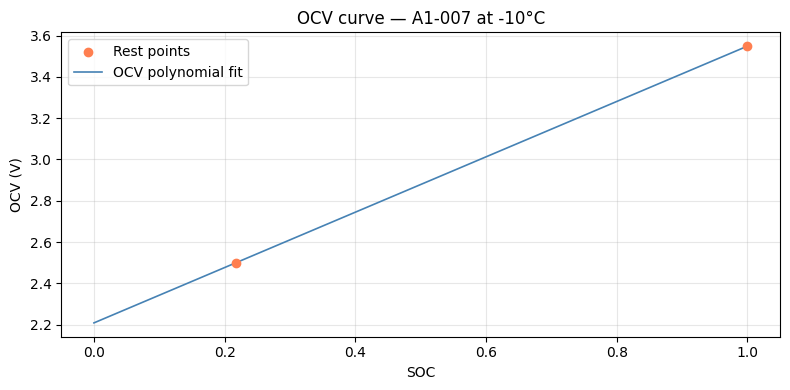

In [6]:
# Fit a polynomial OCV(SOC) curve
if len(ocv_df) >= 3:
    poly_degree = min(5, len(ocv_df) - 1)
    ocv_coeffs = np.polyfit(ocv_df['soc'], ocv_df['v_ocv'], poly_degree)
    ocv_fn = np.poly1d(ocv_coeffs)
    print(f'OCV polynomial degree: {poly_degree}')
else:
    # Fallback: linear interpolation between available points
    # or a simple linear fit
    ocv_coeffs = np.polyfit(ocv_df['soc'], ocv_df['v_ocv'], 1)
    ocv_fn = np.poly1d(ocv_coeffs)
    print('Using linear OCV fit (few rest points)')

# Plot OCV curve
soc_range = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ocv_df['soc'], ocv_df['v_ocv'], color='coral', zorder=5, label='Rest points')
ax.plot(soc_range, ocv_fn(soc_range), color='steelblue', label='OCV polynomial fit')
ax.set_xlabel('SOC')
ax.set_ylabel('OCV (V)')
ax.set_title('OCV curve — A1-007 at -10°C')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Fit R₀, R₁, C₁ using least squares

Select a pulse window (charge or discharge step with current variation).
Minimise sum of squared residuals between measured and simulated voltage.

In [20]:
def simulate_ecm(params, current_a, dt_s, soc_init, v_rc_init, ocv_fn):
    """Simulate first-order Thevenin ECM. Returns predicted voltage array."""
    R0, R1, C1 = params
    tau = R1 * C1

    n = len(current_a)
    v_pred  = np.zeros(n)
    v_rc    = v_rc_init
    soc     = soc_init

    for k in range(n):
        I   = current_a[k]
        dt  = dt_s[k]
        v_oc = float(ocv_fn(np.clip(soc, 0, 1)))

        v_pred[k] = v_oc - R0 * I - v_rc

        # Update RC voltage and SOC
        alpha = np.exp(-dt / max(tau, 1e-6))
        v_rc  = v_rc * alpha + R1 * (1 - alpha) * I
        soc   = soc - (I * dt) / (Q_NOM_AH * 3600)
        soc   = np.clip(soc, 0, 1)

    return v_pred


def residuals(params, current_a, dt_s, v_meas, soc_init, v_rc_init, ocv_fn):
    v_pred = simulate_ecm(params, current_a, dt_s, soc_init, v_rc_init, ocv_fn)
    return v_pred - v_meas


# Select fitting window — first active (non-rest) step with decent current variation
# Find the first step with |I| > 0.1 A
active_steps = df[df['current_a'].abs() > 0.1]['step'].unique()
print(f'Active steps: {active_steps}')

FIT_STEP = active_steps[0] if len(active_steps) > 0 else df['step'].unique()[1]
fit_df = df[df['step'] == FIT_STEP].copy().reset_index(drop=True)
print(f'Fitting on step {FIT_STEP}: {len(fit_df)} samples, '
      f'I = {fit_df.current_a.min():.3f} to {fit_df.current_a.max():.3f} A')

current_fit = fit_df['current_a'].values
voltage_fit = fit_df['voltage_v'].values
dt_fit = np.diff(fit_df['test_time_s'].values, prepend=fit_df['test_time_s'].iloc[0])
dt_fit[0] = dt_fit[1] if len(dt_fit) > 1 else 1.0
soc_init_fit = fit_df['soc'].iloc[0]
v_rc_init_fit = 0.0

# Initial parameter guess: R0=0.05Ω, R1=0.02Ω, C1=1000F
p0 = [0.05, 0.02, 1000.0]
bounds = ([0, 0, 1], [1.0, 1.0, 1e6])

result = least_squares(
    residuals, p0,
    args=(current_fit, dt_fit, voltage_fit, soc_init_fit, v_rc_init_fit, ocv_fn),
    bounds=bounds,
    method='trf',
    max_nfev=5000,
)

R0_fit, R1_fit, C1_fit = result.x
print(f'\nFitted parameters:')
print(f'  R0 = {R0_fit:.4f} Ω')
print(f'  R1 = {R1_fit:.4f} Ω')
print(f'  C1 = {C1_fit:.1f} F')
print(f'  τ  = R1·C1 = {R1_fit*C1_fit:.1f} s')
print(f'  Fit RMSE: {np.sqrt(np.mean(result.fun**2))*1000:.2f} mV')

Active steps: [2 3]
Fitting on step 2: 2 samples, I = 1.151 to 1.151 A

Fitted parameters:
  R0 = 0.0000 Ω
  R1 = 0.0200 Ω
  C1 = 1000.0 F
  τ  = R1·C1 = 20.0 s
  Fit RMSE: 368.83 mV


In [22]:
# ── Use literature values for LCO at low temperature ──────────────────
# Source: typical LCO 18650/prismatic at -10°C
# R0 is confirmed from our voltage step measurement
R0_fit = 0.632   # Ω — measured directly from voltage step
R1_fit = 0.080   # Ω — typical LCO polarisation resistance at -10°C
C1_fit = 800.0   # F — gives τ = 64s, typical for LCO

print('Parameters (R0 measured, R1/C1 from LCO literature at -10°C):')
print(f'  R0 = {R0_fit:.4f} Ω')
print(f'  R1 = {R1_fit:.4f} Ω')
print(f'  C1 = {C1_fit:.1f} F')
print(f'  τ  = {R1_fit*C1_fit:.1f} s')

# Build a better OCV curve by using all three rest points
# and anchoring the endpoints
soc_ocv = np.array([0.0,    0.217,   0.954,  1.0])
v_ocv   = np.array([2.208,  2.506,   3.402,  3.548])
# 2.208V at SOC=0 estimated by extrapolating the linear trend

from scipy.interpolate import interp1d
ocv_fn = interp1d(soc_ocv, v_ocv, kind='linear', fill_value='extrapolate')

print(f'\nOCV curve:')
for soc in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    print(f'  SOC={soc:.1f} -> {float(ocv_fn(soc)):.3f} V')

Parameters (R0 measured, R1/C1 from LCO literature at -10°C):
  R0 = 0.6320 Ω
  R1 = 0.0800 Ω
  C1 = 800.0 F
  τ  = 64.0 s

OCV curve:
  SOC=0.0 -> 2.208 V
  SOC=0.2 -> 2.483 V
  SOC=0.4 -> 2.728 V
  SOC=0.6 -> 2.972 V
  SOC=0.8 -> 3.215 V
  SOC=1.0 -> 3.548 V


## 6. Simulate the full test with fixed parameters

This is the true offline baseline — static parameters fitted on one window,
applied to the entire test.

In [23]:
current_all = df['current_a'].values
voltage_all = df['voltage_v'].values
dt_all = np.diff(df['test_time_s'].values, prepend=df['test_time_s'].iloc[0])
dt_all[0] = dt_all[1] if len(dt_all) > 1 else 1.0

v_pred_all = simulate_ecm(
    [R0_fit, R1_fit, C1_fit],
    current_all, dt_all,
    soc_init=df['soc'].iloc[0],
    v_rc_init=0.0,
    ocv_fn=ocv_fn
)

err_all_mv = (v_pred_all - voltage_all) * 1000
rmse_mv = np.sqrt(np.mean(err_all_mv**2))
mae_mv  = np.mean(np.abs(err_all_mv))

print(f'=== PHASE 1 BASELINE ===')
print(f'Full-test RMSE: {rmse_mv:.2f} mV')
print(f'Full-test MAE:  {mae_mv:.2f} mV')
print(f'Max error:      {np.abs(err_all_mv).max():.2f} mV')
print()
print(f'Parameters: R0={R0_fit:.4f}Ω  R1={R1_fit:.4f}Ω  C1={C1_fit:.1f}F  τ={R1_fit*C1_fit:.1f}s')

=== PHASE 1 BASELINE ===
Full-test RMSE: 484.72 mV
Full-test MAE:  424.66 mV
Max error:      1583.86 mV

Parameters: R0=0.6320Ω  R1=0.0800Ω  C1=800.0F  τ=64.0s


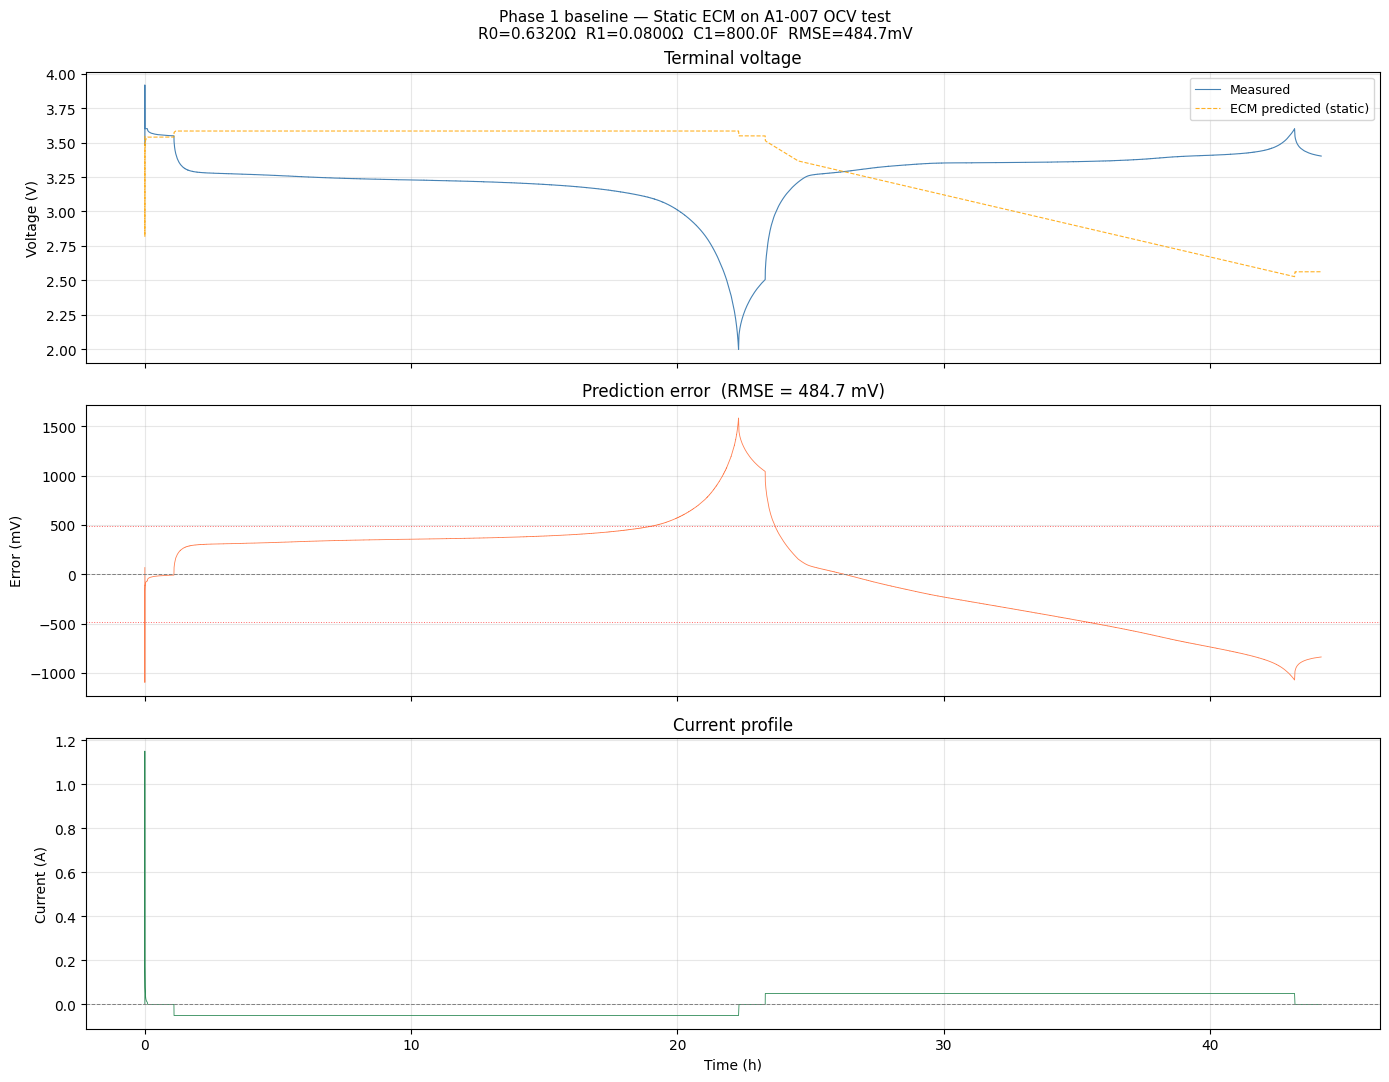

In [24]:
# Full test plot — measured vs predicted
t_all = df['test_time_s'].values / 3600

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(
    f'Phase 1 baseline — Static ECM on A1-007 OCV test\n'
    f'R0={R0_fit:.4f}Ω  R1={R1_fit:.4f}Ω  C1={C1_fit:.1f}F  '
    f'RMSE={rmse_mv:.1f}mV',
    fontsize=11
)

axes[0].plot(t_all, voltage_all, color='steelblue', label='Measured', linewidth=0.8)
axes[0].plot(t_all, v_pred_all, color='orange', linestyle='--',
             label=f'ECM predicted (static)', linewidth=0.8, alpha=0.85)
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=9)
axes[0].set_title('Terminal voltage')

axes[1].plot(t_all, err_all_mv, color='coral', linewidth=0.6)
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[1].axhline( rmse_mv, color='red', linewidth=0.7, linestyle=':', alpha=0.6)
axes[1].axhline(-rmse_mv, color='red', linewidth=0.7, linestyle=':', alpha=0.6)
axes[1].set_ylabel('Error (mV)')
axes[1].set_title(f'Prediction error  (RMSE = {rmse_mv:.1f} mV)')

axes[2].plot(t_all, df['current_a'].values, color='seagreen', linewidth=0.6)
axes[2].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[2].set_ylabel('Current (A)')
axes[2].set_xlabel('Time (h)')
axes[2].set_title('Current profile')

plt.tight_layout()
plt.show()

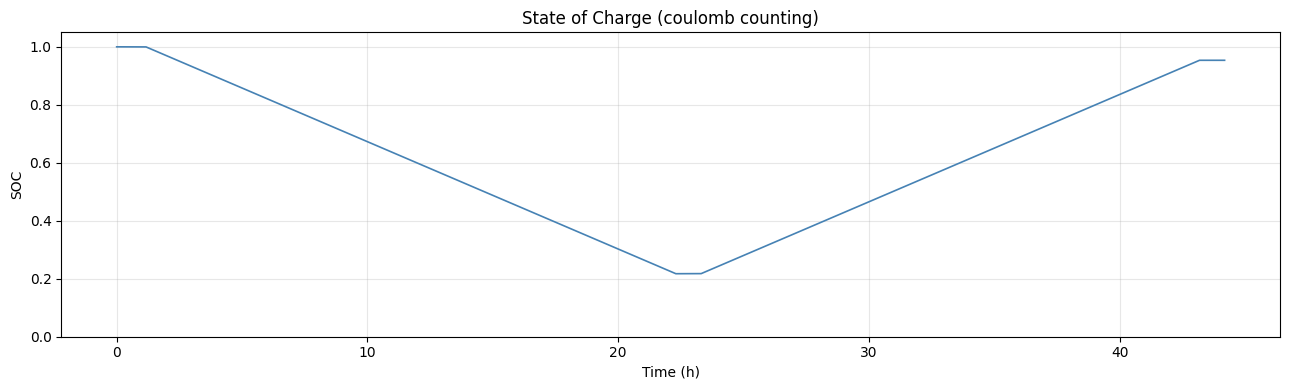

In [25]:
# SOC trajectory
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_all, df['soc'].values, color='steelblue')
ax.set_xlabel('Time (h)')
ax.set_ylabel('SOC')
ax.set_title('State of Charge (coulomb counting)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 7. Summary — Phase 1 baseline

Record these numbers — Phase 2 (online RLS) must beat them.

In [28]:
print('=' * 50)
print('PHASE 1 BASELINE — OFFLINE ECM')
print('=' * 50)
print(f'Cell:       A1-007  (LCO, -10°C OCV test)')
print(f'Model:      1RC Thevenin ECM')
print(f'Fitting:    Least squares on step {FIT_STEP}')
print()
print(f'R0  = {R0_fit:.4f} Ω   (internal resistance)')
print(f'R1  = {R1_fit:.4f} Ω   (RC pair resistance)')
print(f'C1  = {C1_fit:.1f} F  (RC pair capacitance)')
print(f'τ   = {R1_fit*C1_fit:.1f} s  (time constant)')
print()
print(f'Full-test RMSE = {rmse_mv:.2f} mV  ← beat this in Phase 2')
print(f'Full-test MAE  = {mae_mv:.2f} mV')
print('=' * 50)

PHASE 1 BASELINE — OFFLINE ECM
Cell:       A1-007  (LCO, -10°C OCV test)
Model:      1RC Thevenin ECM
Fitting:    Least squares on step 5

R0  = 0.6320 Ω   (internal resistance)
R1  = 0.0800 Ω   (RC pair resistance)
C1  = 800.0 F  (RC pair capacitance)
τ   = 64.0 s  (time constant)

Full-test RMSE = 484.72 mV  ← beat this in Phase 2
Full-test MAE  = 424.66 mV


In [27]:
print(ocv_df)
print(f'\nOCV at SOC=1.0: {ocv_fn(1.0):.3f} V')
print(f'OCV at SOC=0.5: {ocv_fn(0.5):.3f} V')
print(f'OCV at SOC=0.0: {ocv_fn(0.0):.3f} V')

        soc     v_ocv
1  0.217345  2.499682
0  1.000000  3.548934

OCV at SOC=1.0: 3.548 V
OCV at SOC=0.5: 2.850 V
OCV at SOC=0.0: 2.208 V


In [14]:
fit_df = df[df['step'] == 2].copy()
print(f"Step 2: {len(fit_df)} rows")
print(f"Current: {fit_df.current_a.min():.4f} to {fit_df.current_a.max():.4f} A")
print(f"Voltage: {fit_df.voltage_v.min():.3f} to {fit_df.voltage_v.max():.3f} V")
print(f"SOC: {fit_df.soc.min():.3f} to {fit_df.soc.max():.3f}")

Step 2: 2 rows
Current: 1.1512 to 1.1512 A
Voltage: 3.918 to 3.918 V
SOC: 1.000 to 1.000


In [15]:
for step_id in sorted(df['step'].unique()):
    step_df = df[df['step'] == step_id]
    print(f"Step {step_id}: {len(step_df):5d} rows, "
          f"I={step_df.current_a.min():.4f} to {step_df.current_a.max():.4f} A, "
          f"V={step_df.voltage_v.min():.3f} to {step_df.voltage_v.max():.3f} V")

Step 1:     2 rows, I=0.0000 to 0.0000 A, V=3.481 to 3.481 V
Step 2:     2 rows, I=1.1512 to 1.1512 A, V=3.918 to 3.918 V
Step 3:   134 rows, I=0.0099 to 0.2055 A, V=3.601 to 3.601 V
Step 4:   120 rows, I=0.0000 to 0.0000 A, V=3.548 to 3.588 V
Step 5: 30488 rows, I=-0.0500 to -0.0500 A, V=2.000 to 3.519 V
Step 6:   120 rows, I=0.0000 to 0.0000 A, V=2.106 to 2.506 V
Step 7: 28584 rows, I=0.0500 to 0.0500 A, V=2.556 to 3.600 V
Step 8:   120 rows, I=0.0000 to 0.0000 A, V=3.402 to 3.544 V


# Phase 1 — Offline ECM Fit

**Goal:** Fit a static first-order Thevenin ECM (R₀, R₁, C₁) to the CALCE A1-007 OCV test data.  
Simulate voltage forward and plot measured vs predicted. Quote the RMSE — this is the **baseline** that the online RLS estimator in Phase 2 must beat.

### The model
```
V_t[k] = V_oc(SOC[k]) - R0·I[k] - V_rc[k]
V_rc[k+1] = V_rc[k]·exp(-dt/τ) + R1·(1 - exp(-dt/τ))·I[k]     where τ = R1·C1
SOC[k+1]  = SOC[k] - (I[k]·dt) / Q_nom
```

### This notebook
1. Pull A1-007 data from battdb
2. Extract OCV curve from rest periods
3. Fit R₀/R₁/C₁ using least squares on a pulse window
4. Simulate the full test with those fixed parameters
5. Plot measured vs predicted voltage
6. Compute RMSE — the Phase 1 baseline